# Batch Normalization

In [46]:
import os

# study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251211-6/pablomer_optuna_20251211'
study_directory = '/pdo/users/pablomer/mnt/tess/models/vetting/20251219-batchnormstudy/pablomer_optuna_20251219/'

file_name = 'optuna_trials_trial_100.csv'

path = os.path.join(study_directory, file_name)

In [47]:
print(path)
import pandas as pd

df=pd.read_csv(path)

df.head()

/pdo/users/pablomer/mnt/tess/models/vetting/20251219-batchnormstudy/pablomer_optuna_20251219/optuna_trials_trial_100.csv


,trial_number,value,state,use_batch_norm,learning_rate,weight_decay,pre_logits_dropout_rate
0,0,0.963466,COMPLETE,False,0.000080,0.041917,0.283229
1,1,0.979301,COMPLETE,False,0.000003,0.001000,0.000000
2,2,0.966395,COMPLETE,True,0.000080,0.022361,0.200000
3,3,0.964804,COMPLETE,False,0.000080,0.105737,0.100000
4,4,0.977086,COMPLETE,True,0.000010,0.004729,0.300000


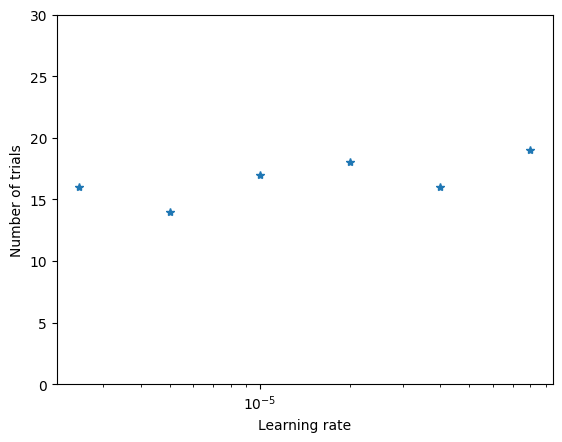

In [48]:
import matplotlib.pyplot as plt

lr_counts = df['learning_rate'].value_counts().sort_index()

plt.figure()
plt.plot(lr_counts.index, lr_counts.values,'*')
plt.xlabel('Learning rate')
plt.ylabel('Number of trials')
plt.xscale('log')  # recommended for learning rates
plt.ylim(0,30)
plt.show()


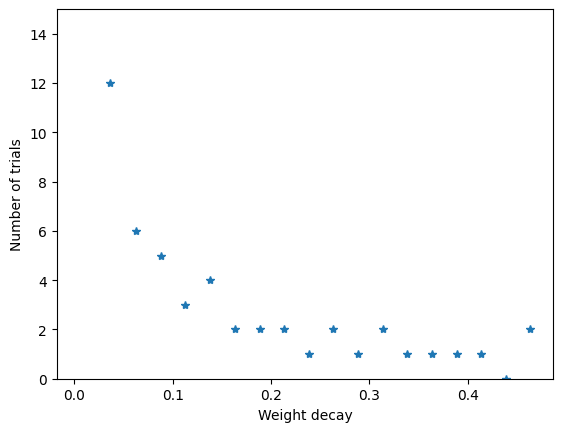

In [49]:
import numpy as np
import matplotlib.pyplot as plt

wd = df['weight_decay'].values

# Log-spaced bins
# bins = np.logspace(
#     np.log10(wd.min()),
#     np.log10(wd.max()),
#     20  # number of bins
# )

bins = np.linspace(wd.min(), wd.max(), 20)

counts, edges = np.histogram(wd, bins=bins)
centers = np.sqrt(edges[:-1] * edges[1:])  # geometric mean for log bins

plt.figure()
plt.plot(centers, counts, '*')
# plt.xscale('log')
plt.xlabel('Weight decay')
plt.ylabel('Number of trials')
plt.ylim(0, 15)
plt.show()

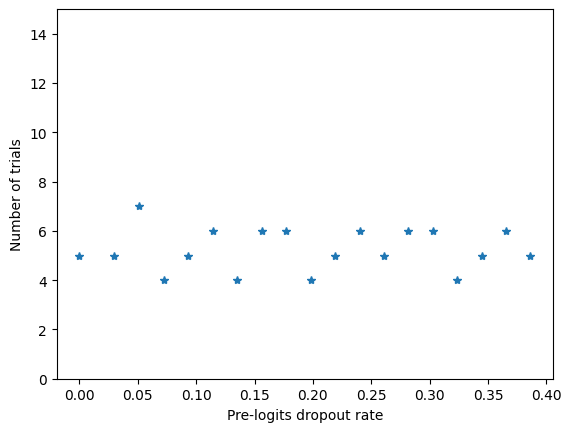

In [50]:
import numpy as np
import matplotlib.pyplot as plt

wd = df['pre_logits_dropout_rate'].values

# Log-spaced bins
# bins = np.logspace(
#     np.log10(wd.min()),
#     np.log10(wd.max()),
#     20  # number of bins
# )

bins = np.linspace(wd.min(), wd.max(), 20)

counts, edges = np.histogram(wd, bins=bins)
centers = np.sqrt(edges[:-1] * edges[1:])  # geometric mean for log bins

plt.figure()
plt.plot(centers, counts, '*')
# plt.xscale('log')
plt.xlabel('Pre-logits dropout rate')
plt.ylabel('Number of trials')
plt.ylim(0, 15)
plt.show()

In [51]:
df_batch_norm=df[df['use_batch_norm']==True]
df_no_batch_norm=df[df['use_batch_norm']==False]

In [52]:
df_batch_norm['value']

2     0.966395
4     0.977086
6     0.975215
10    0.972133
15    0.969084
16    0.981957
18    0.982157
19    0.981892
20    0.980986
21    0.965530
22    0.982244
23    0.943893
28    0.976340
30    0.972973
32    0.981742
34    0.974608
35    0.972653
37    0.947716
38    0.964411
39    0.949082
40    0.977172
42    0.954575
43    0.967659
46    0.967133
47    0.971940
48    0.981490
55    0.974897
56    0.983661
63    0.979571
64    0.980940
65    0.955260
67    0.982087
69    0.974671
70    0.966627
72    0.979394
74    0.978696
75    0.960982
77    0.967807
82    0.982785
83    0.970547
92    0.966482
97    0.966010
98    0.979607
Name: value, dtype: float64

Text(0, 0.5, 'PR AUC')

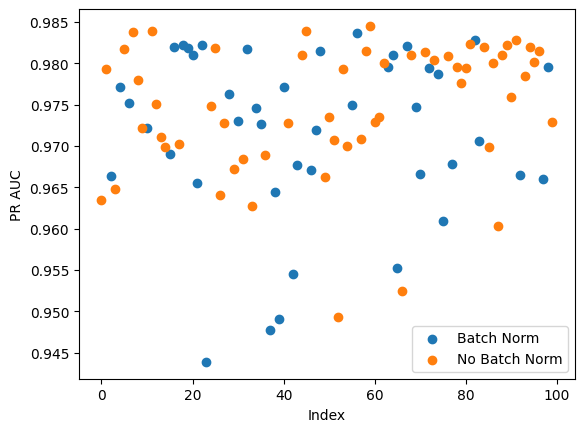

In [53]:
import matplotlib.pyplot as plt

plt.scatter(df_batch_norm['value'].index, df_batch_norm['value'].values, label='Batch Norm')
plt.scatter(df_no_batch_norm['value'].index, df_no_batch_norm['value'].values, label = 'No Batch Norm')
plt.legend()
plt.xlabel('Index')
plt.ylabel('PR AUC')

In [54]:
batch_norm=df_batch_norm['value'].values
no_batch_norm=df_no_batch_norm['value'].values

threshold_1=0.97
threshold_2=0.96


print(f'Batch Norm. >={threshold_1}: {(batch_norm>=threshold_1).sum()}, >={threshold_2}: {(batch_norm>=threshold_2).sum()}')
print(f'No Batch Norm. >={threshold_1}: {(no_batch_norm>=threshold_1).sum()}, >={threshold_2}: {(no_batch_norm>=threshold_2).sum()}')

Batch Norm. >=0.97: 27, >=0.96: 38
No Batch Norm. >=0.97: 43, >=0.96: 55


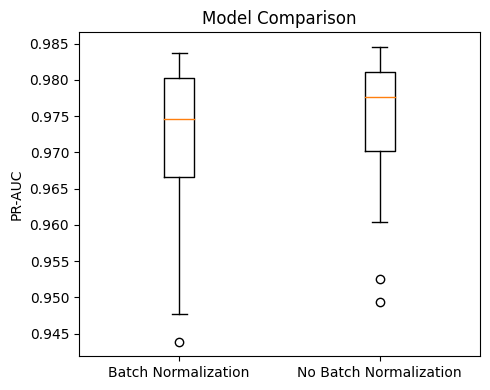

In [55]:
import matplotlib.pyplot as plt

data = [batch_norm, no_batch_norm]
labels = ["Batch Normalization", "No Batch Normalization"]

plt.figure(figsize=(5, 4))
plt.boxplot(data, labels=labels, showfliers=True)
plt.ylabel("PR-AUC")  # or whatever metric
plt.title("Model Comparison")

plt.tight_layout()
plt.show()

In [56]:
import matplotlib.pyplot as plt
import numpy as np

def plot_boolean_vs_value(df, x_col, y_col='value', title='', jitter_width=0.05):
    """
    Scatter + violin overlaid for a boolean x-axis column vs. a numeric y-axis column.
    Annotates the count of points above and the best value below each category.
    """
    categories = [False, True]
    data = [df[df[x_col] == cat][y_col].values for cat in categories]
    counts = [len(vals) for vals in data]

    # Prepare figure
    fig, ax = plt.subplots(figsize=(6, 4))

    # 1) Violin plot
    ax.violinplot(data, positions=[0, 1], widths=0.6)

    # 2) Scatter with jitter
    for pos, vals in zip([0, 1], data):
        x_jitter = np.random.normal(loc=pos, scale=jitter_width, size=len(vals))
        ax.scatter(x_jitter, vals, alpha=0.6)

    # 3) Compute y-range and offsets
    all_vals = np.concatenate(data) if any(len(vals) > 0 for vals in data) else np.array([0])
    y_max = all_vals.max()
    y_min = all_vals.min()
    offset = (y_max - y_min) * 0.05 if y_max != y_min else 0.05

    # 4) Annotate counts above each category
    for pos, count in zip([0, 1], counts):
        ax.text(pos, y_max + offset, f'n={count}', ha='center', va='bottom', fontsize=9)

    # 5) Annotate best value below each category
    for pos, vals in zip([0, 1], data):
        if len(vals) > 0:
            best_val = vals.max()
            # ax.text(pos, y_min - offset * 4,
                    # f'best: {best_val:.3f}',
                    # ha='center', va='top', fontsize=9, fontweight='bold')

    # 6) Adjust y-limits to fit annotations
    ax.set_ylim(y_min - offset * 2, y_max + offset * 3)

    # 7) Labels, ticks, and title
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['False', 'True'])
    ax.set_xlabel(x_col)
    ax.set_ylabel('PR AUC')
    ax.set_ylim(0.9,0.99)
    ax.set_title(title, pad=20)

    plt.tight_layout()
    plt.show()


def calculate_above_threshold(df, column_name, threshold_1, threshold_2):
    df_true = df[df[column_name]==True]
    df_false = df[df[column_name]==False]

    print(f'{column_name} True: {df_true[column_name].shape}, False: {df_false[column_name].shape}')

    true_above_threshold_1 = df_true[df_true['value']>=threshold_1].shape[0]
    true_above_threshold_2 = df_true[df_true['value']>=threshold_2].shape[0]

    false_above_threshold_1 = df_false[df_false['value']>=threshold_1].shape[0]
    false_above_threshold_2 = df_false[df_false['value']>=threshold_2].shape[0]

    print(f'{column_name} True >={threshold_1}: {true_above_threshold_1}, >={threshold_2}: {true_above_threshold_2}')
    print(f'{column_name} False >={threshold_1}: {false_above_threshold_1}, >={threshold_2}: {false_above_threshold_2}')


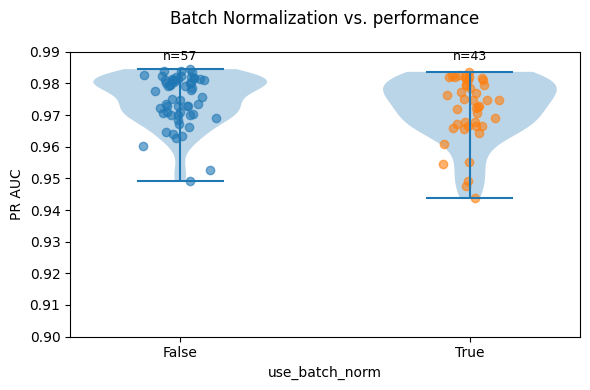

use_batch_norm True: (43,), False: (57,)
use_batch_norm True >=0.97: 27, >=0.96: 38
use_batch_norm False >=0.97: 43, >=0.96: 55


In [57]:

# Usage Example (if `combined` exists):
plot_boolean_vs_value(df, 'use_batch_norm', title='Batch Normalization vs. performance')
# plot_boolean_vs_value(df_no_batch_norm, 'use_batch_norm', title='Batch Normalization vs. performance')
calculate_above_threshold(df, 'use_batch_norm', 0.97, 0.96)


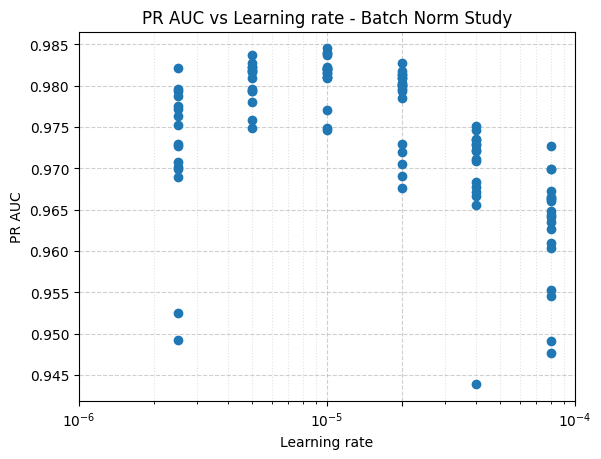

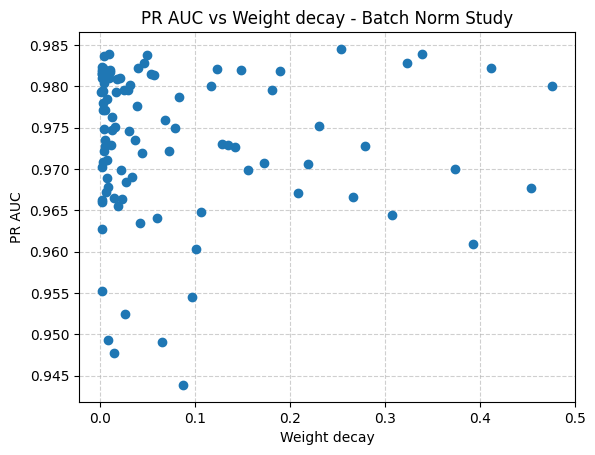

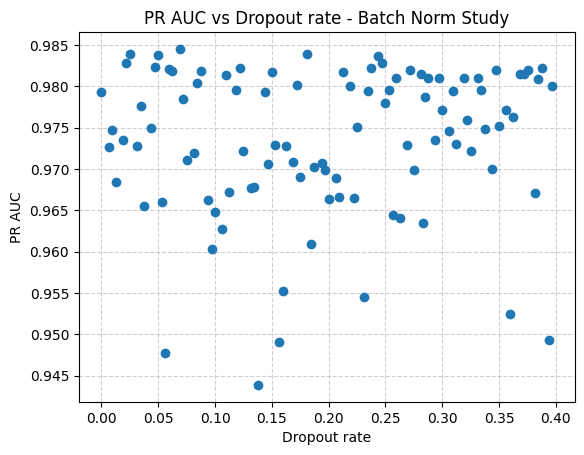

In [58]:
plt.plot(df['learning_rate'],df['value'],'o')
plt.xscale('log')
plt.xticks([1e-6, 1e-5, 2e-5, 1e-4])
plt.xlabel('Learning rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Learning rate - Batch Norm Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()


plt.plot(df['weight_decay'],df['value'],'o')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Weight decay')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Weight decay - Batch Norm Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()


#plot for dropout rate
plt.plot(df['pre_logits_dropout_rate'],df['value'],'o')
plt.xlabel('Dropout rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Dropout rate - Batch Norm Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()


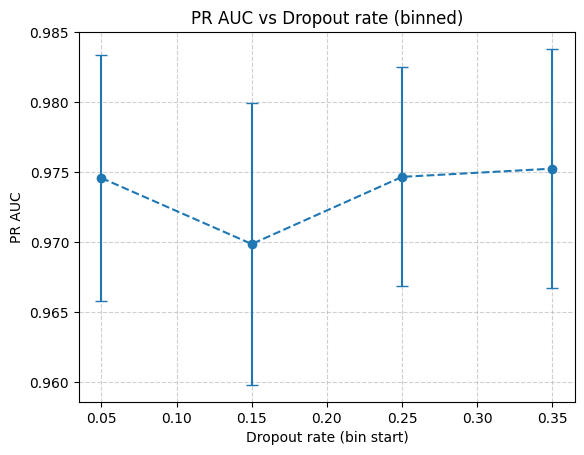

In [59]:
import numpy as np
import matplotlib.pyplot as plt

dropout_bins = [0.0, 0.1, 0.2, 0.3]

bin_means = []
bin_stds = []

for b in dropout_bins:
    mask = (
        (df['pre_logits_dropout_rate'] >= b) &
        (df['pre_logits_dropout_rate'] < b + 0.1)
    )
    bin_df = df[mask]

    bin_means.append(bin_df['value'].mean())
    bin_stds.append(bin_df['value'].std())

# Plot with error bars (much better than raw dots)
bin_centers = [b + 0.05 for b in dropout_bins]

plt.errorbar(
    bin_centers,
    bin_means,
    yerr=bin_stds,
    fmt='o--',
    capsize=4
)

plt.xlabel("Dropout rate (bin start)")
plt.ylabel("PR AUC")
plt.title("PR AUC vs Dropout rate (binned)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

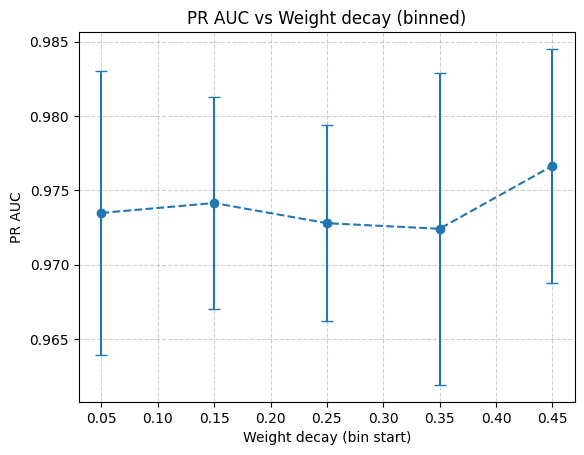

In [60]:
import numpy as np
import matplotlib.pyplot as plt

dropout_bins = [0.0, 0.1, 0.2, 0.3, 0.4]

bin_means = []
bin_stds = []

for b in dropout_bins:
    mask = (
        (df['weight_decay'] >= b) &
        (df['weight_decay'] < b + 0.1)
    )
    bin_df = df[mask]

    bin_means.append(bin_df['value'].mean())
    bin_stds.append(bin_df['value'].std())

# Plot with error bars (much better than raw dots)
bin_centers = [b + 0.05 for b in dropout_bins]

plt.errorbar(
    bin_centers,
    bin_means,
    yerr=bin_stds,
    fmt='o--',
    capsize=4
)

plt.xlabel("Weight decay (bin start)")
plt.ylabel("PR AUC")
plt.title("PR AUC vs Weight decay (binned)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

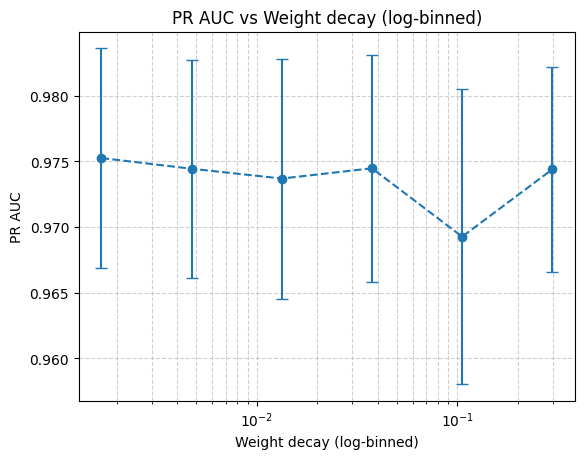

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1) DEFINE LOG-SPACED BINS
# ---------------------------

n_bins = 6  # adjust if you want more / fewer buckets
wd_bins = np.logspace(np.log10(1e-3), np.log10(0.5), n_bins + 1)

# ---------------------------
# 2) BIN & AGGREGATE
# ---------------------------

bin_means = []
bin_stds = []
bin_centers = []

for lo, hi in zip(wd_bins[:-1], wd_bins[1:]):
    mask = (
        (df["weight_decay"] >= lo) &
        (df["weight_decay"] < hi)
    )
    bin_df = df[mask]

    bin_means.append(bin_df["value"].mean())
    bin_stds.append(bin_df["value"].std())

    # geometric mean is the correct center for log bins
    bin_centers.append(np.sqrt(lo * hi))

# ---------------------------
# 3) PLOT
# ---------------------------

plt.errorbar(
    bin_centers,
    bin_means,
    yerr=bin_stds,
    fmt="o--",
    capsize=4,
)

plt.xscale("log")
plt.xlabel("Weight decay (log-binned)")
plt.ylabel("PR AUC")
plt.title("PR AUC vs Weight decay (log-binned)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

# Next Study - Pretraining

In [62]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251211-5/pablomer_optuna_20251211'

file_name = 'optuna_trials_trial_90.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

df.head()

/pdo/users/pablomer/mnt/tess/models/vetting/20251211-5/pablomer_optuna_20251211/optuna_trials_trial_90.csv


,trial_number,value,state,init_from_pretrained_model,learning_rate,weight_decay,pre_logits_dropout_rate
0,0,0.937515,COMPLETE,False,0.000003,0.433222,0.240446
1,1,0.924695,COMPLETE,True,0.000003,0.001000,0.000000
2,2,0.972187,COMPLETE,False,0.000010,0.250500,0.200000
3,3,0.941838,COMPLETE,False,0.000003,0.375250,0.100000
4,4,0.976714,COMPLETE,True,0.000010,0.125750,0.300000


In [63]:
def calculate_above_threshold(df, column_name, threshold_1, threshold_2):
    df_true = df[df[column_name]==True]
    df_false = df[df[column_name]==False]

    print(f'{column_name} True: {df_true[column_name].shape}, False: {df_false[column_name].shape}')

    true_above_threshold_1 = df_true[df_true['value']>=threshold_1].shape[0]
    true_above_threshold_2 = df_true[df_true['value']>=threshold_2].shape[0]

    false_above_threshold_1 = df_false[df_false['value']>=threshold_1].shape[0]
    false_above_threshold_2 = df_false[df_false['value']>=threshold_2].shape[0]

    print(f'{column_name} True >={threshold_1}: {true_above_threshold_1}, >={threshold_2}: {true_above_threshold_2}')
    print(f'{column_name} False >={threshold_1}: {false_above_threshold_1}, >={threshold_2}: {false_above_threshold_2}')


In [64]:
# calculate_above_threshold(df, 'use_batch_norm', 0.97, 0.96)
calculate_above_threshold(df, 'init_from_pretrained_model', 0.97, 0.96)

init_from_pretrained_model True: (49,), False: (41,)
init_from_pretrained_model True >=0.97: 25, >=0.96: 40
init_from_pretrained_model False >=0.97: 12, >=0.96: 23


In [65]:
import matplotlib.pyplot as plt
import numpy as np

def plot_boolean_vs_value(df, x_col, y_col='value', title='', jitter_width=0.05, ylim=(0.9,0.99)):
    """
    Scatter + violin overlaid for a boolean x-axis column vs. a numeric y-axis column.
    Annotates the count of points above and the best value below each category.
    """
    categories = [False, True]
    data = [df[df[x_col] == cat][y_col].values for cat in categories]
    counts = [len(vals) for vals in data]

    # Prepare figure
    fig, ax = plt.subplots(figsize=(6, 4))

    # 1) Violin plot
    ax.violinplot(data, positions=[0, 1], widths=0.6)

    # 2) Scatter with jitter
    for pos, vals in zip([0, 1], data):
        x_jitter = np.random.normal(loc=pos, scale=jitter_width, size=len(vals))
        ax.scatter(x_jitter, vals, alpha=0.6)

    # 3) Compute y-range and offsets
    all_vals = np.concatenate(data) if any(len(vals) > 0 for vals in data) else np.array([0])
    y_max = all_vals.max()
    y_min = all_vals.min()
    offset = (y_max - y_min) * 0.05 if y_max != y_min else 0.05

    # 4) Annotate counts above each category
    for pos, count in zip([0, 1], counts):
        ax.text(pos, y_max + offset, f'n={count}', ha='center', va='bottom', fontsize=9)

    # 5) Annotate best value below each category
    for pos, vals in zip([0, 1], data):
        if len(vals) > 0:
            best_val = vals.max()
            # ax.text(pos, y_min - offset * 4,
                    # f'best: {best_val:.3f}',
                    # ha='center', va='top', fontsize=9, fontweight='bold')

    # 6) Adjust y-limits to fit annotations
    ax.set_ylim(y_min - offset * 2, y_max + offset * 3)

    # 7) Labels, ticks, and title
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['False', 'True'])
    ax.set_xlabel(x_col)
    ax.set_ylabel('PR AUC')
    # ax.set_ylim(0.9,0.99)
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_title(title, pad=20)

    plt.tight_layout()
    plt.show()


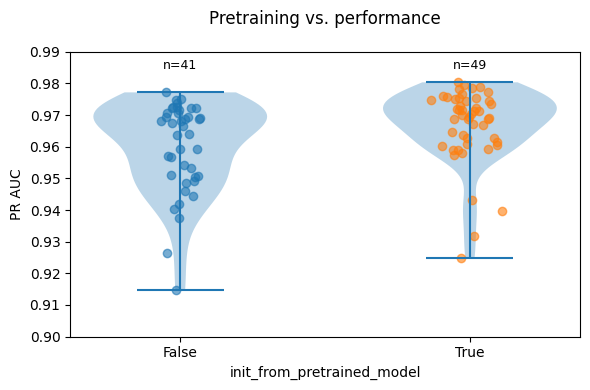

init_from_pretrained_model True: (49,), False: (41,)
init_from_pretrained_model True >=0.97: 25, >=0.96: 40
init_from_pretrained_model False >=0.97: 12, >=0.96: 23


In [66]:
# Usage Example (if `combined` exists):
plot_boolean_vs_value(df, 'init_from_pretrained_model', title='Pretraining vs. performance')
calculate_above_threshold(df, 'init_from_pretrained_model', 0.97, 0.96)

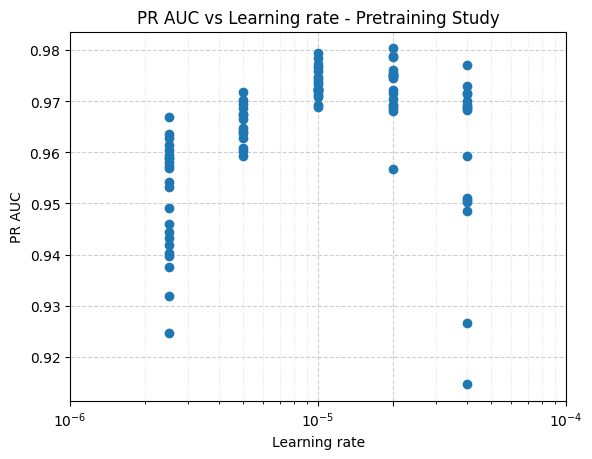

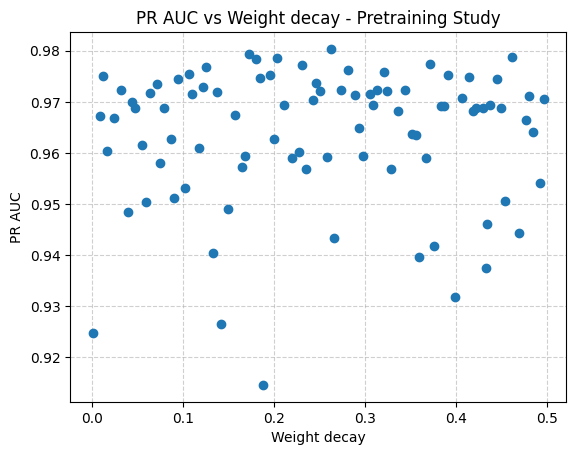

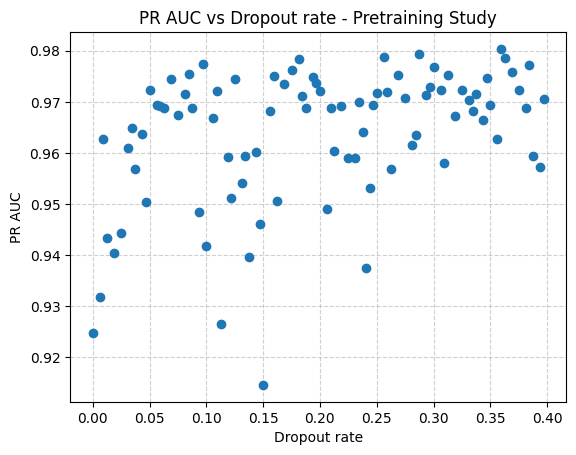

In [67]:
plt.plot(df['learning_rate'],df['value'],'o')
plt.xscale('log')
plt.xticks([1e-6, 1e-5, 2e-5, 1e-4])
plt.xlabel('Learning rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Learning rate - Pretraining Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()


plt.plot(df['weight_decay'],df['value'],'o')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Weight decay')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Weight decay - Pretraining Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()


#plot for dropout rate
plt.plot(df['pre_logits_dropout_rate'],df['value'],'o')
plt.xlabel('Dropout rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Dropout rate - Pretraining Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()


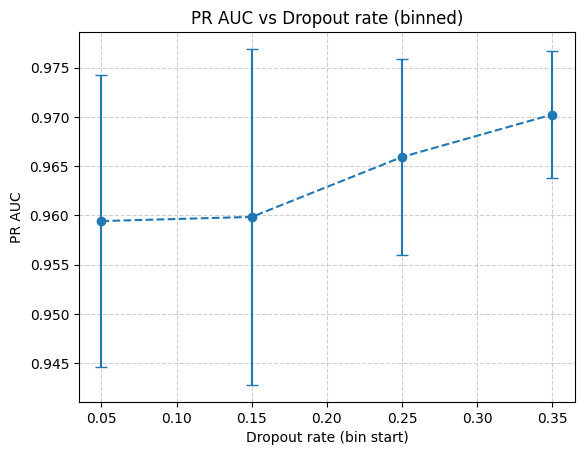

In [68]:
import numpy as np
import matplotlib.pyplot as plt

dropout_bins = [0.0, 0.1, 0.2, 0.3]

bin_means = []
bin_stds = []

for b in dropout_bins:
    mask = (
        (df['pre_logits_dropout_rate'] >= b) &
        (df['pre_logits_dropout_rate'] < b + 0.1)
    )
    bin_df = df[mask]

    bin_means.append(bin_df['value'].mean())
    bin_stds.append(bin_df['value'].std())

# Plot with error bars (much better than raw dots)
bin_centers = [b + 0.05 for b in dropout_bins]

plt.errorbar(
    bin_centers,
    bin_means,
    yerr=bin_stds,
    fmt='o--',
    capsize=4
)

plt.xlabel("Dropout rate (bin start)")
plt.ylabel("PR AUC")
plt.title("PR AUC vs Dropout rate (binned)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

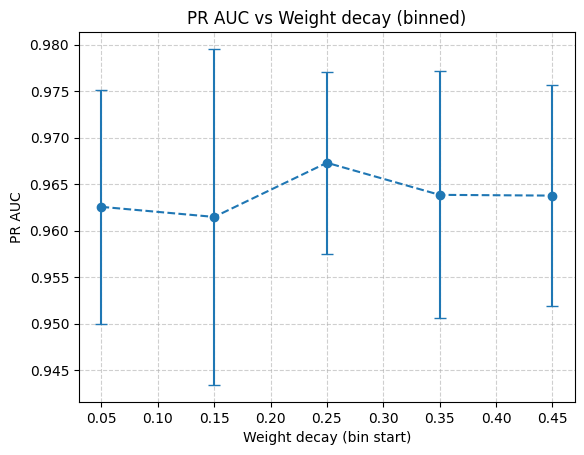

In [69]:
import numpy as np
import matplotlib.pyplot as plt

dropout_bins = [0.0, 0.1, 0.2, 0.3, 0.4]

bin_means = []
bin_stds = []

for b in dropout_bins:
    mask = (
        (df['weight_decay'] >= b) &
        (df['weight_decay'] < b + 0.1)
    )
    bin_df = df[mask]

    bin_means.append(bin_df['value'].mean())
    bin_stds.append(bin_df['value'].std())

# Plot with error bars (much better than raw dots)
bin_centers = [b + 0.05 for b in dropout_bins]

plt.errorbar(
    bin_centers,
    bin_means,
    yerr=bin_stds,
    fmt='o--',
    capsize=4
)

plt.xlabel("Weight decay (bin start)")
plt.ylabel("PR AUC")
plt.title("PR AUC vs Weight decay (binned)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Another Study - Random Reverse Time Series

/pdo/users/pablomer/mnt/tess/models/vetting/20251211-4/pablomer_optuna_20251211/optuna_trials_trial_99.csv
   trial_number     value     state  random_reverse_time_series  \
0             0  0.957389  COMPLETE                       False   
1             1  0.926079  COMPLETE                        True   
2             2  0.968699  COMPLETE                       False   
3             3  0.947431  COMPLETE                       False   
4             4  0.971616  COMPLETE                        True   

   learning_rate  weight_decay  pre_logits_dropout_rate  
0       0.000003      0.433222                 0.240446  
1       0.000003      0.001000                 0.000000  
2       0.000010      0.250500                 0.200000  
3       0.000003      0.375250                 0.100000  
4       0.000010      0.125750                 0.300000  


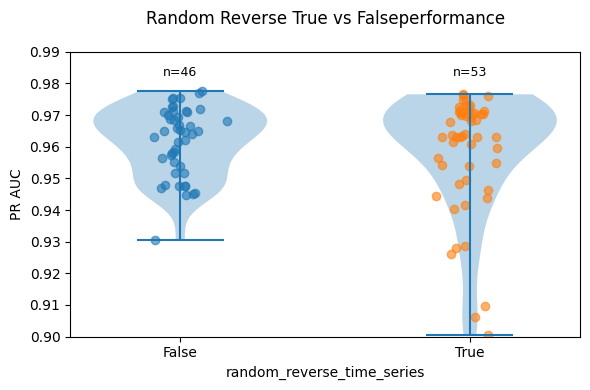

random_reverse_time_series True: (53,), False: (46,)
random_reverse_time_series True >=0.97: 20, >=0.96: 35
random_reverse_time_series False >=0.97: 13, >=0.96: 28


In [70]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251211-4/pablomer_optuna_20251211'

file_name = 'optuna_trials_trial_99.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'random_reverse_time_series', title='Random Reverse True vs Falseperformance')
calculate_above_threshold(df, 'random_reverse_time_series', 0.97, 0.96)

In [71]:
df

,trial_number,value,state,random_reverse_time_series,learning_rate,weight_decay,pre_logits_dropout_rate
0,0,0.957389,COMPLETE,False,0.000003,0.433222,0.240446
1,1,0.926079,COMPLETE,True,0.000003,0.001000,0.000000
2,2,0.968699,COMPLETE,False,0.000010,0.250500,0.200000
3,3,0.947431,COMPLETE,False,0.000003,0.375250,0.100000
4,4,0.971616,COMPLETE,True,0.000010,0.125750,0.300000
...,...,...,...,...,...,...,...
94,94,0.957933,COMPLETE,False,0.000003,0.402539,0.271875
95,95,0.970884,COMPLETE,False,0.000010,0.277789,0.171875
96,96,0.972776,COMPLETE,False,0.000010,0.028289,0.371875
97,97,0.963135,COMPLETE,True,0.000005,0.020492,0.053125


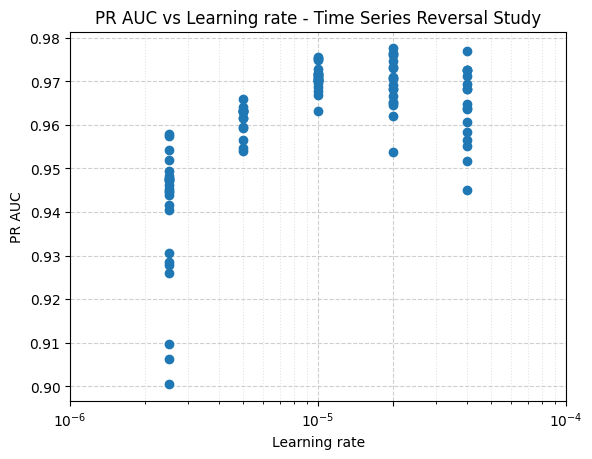

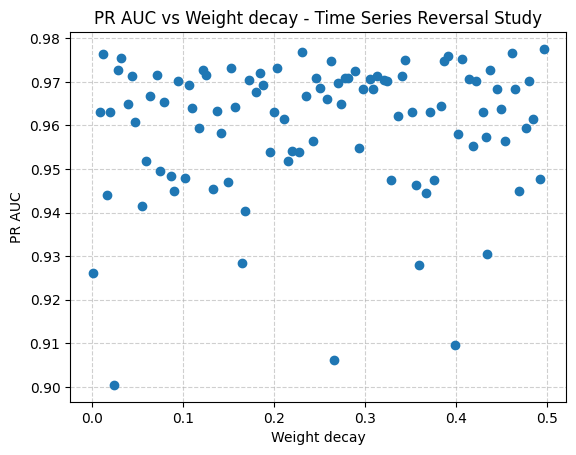

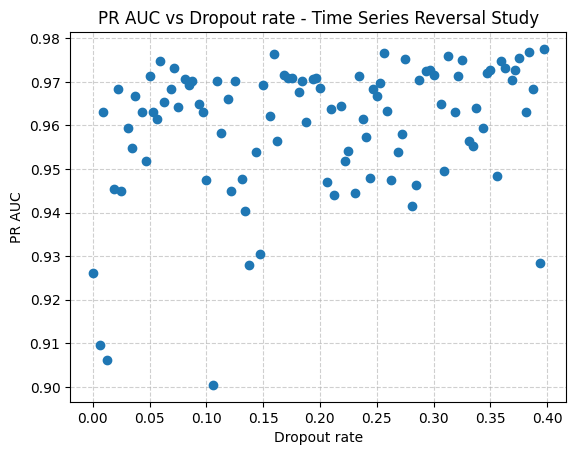

In [72]:
plt.plot(df['learning_rate'],df['value'],'o')
plt.xscale('log')
plt.xticks([1e-6, 1e-5, 2e-5, 1e-4])
plt.xlabel('Learning rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Learning rate - Time Series Reversal Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()


plt.plot(df['weight_decay'],df['value'],'o')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Weight decay')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Weight decay - Time Series Reversal Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()


#plot for dropout rate
plt.plot(df['pre_logits_dropout_rate'],df['value'],'o')
plt.xlabel('Dropout rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Dropout rate - Time Series Reversal Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()


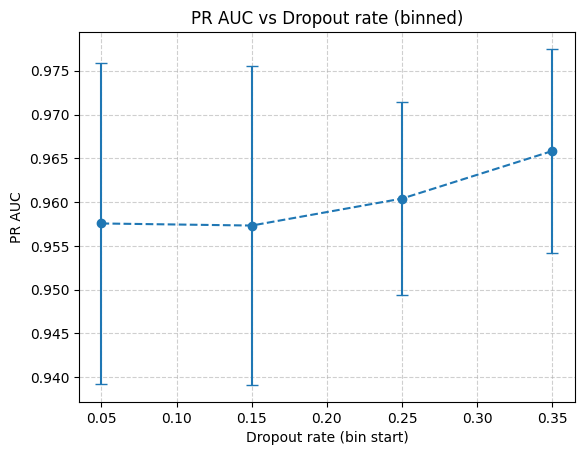

In [73]:
import numpy as np
import matplotlib.pyplot as plt

dropout_bins = [0.0, 0.1, 0.2, 0.3]

bin_means = []
bin_stds = []

for b in dropout_bins:
    mask = (
        (df['pre_logits_dropout_rate'] >= b) &
        (df['pre_logits_dropout_rate'] < b + 0.1)
    )
    bin_df = df[mask]

    bin_means.append(bin_df['value'].mean())
    bin_stds.append(bin_df['value'].std())

# Plot with error bars (much better than raw dots)
bin_centers = [b + 0.05 for b in dropout_bins]

plt.errorbar(
    bin_centers,
    bin_means,
    yerr=bin_stds,
    fmt='o--',
    capsize=4
)

plt.xlabel("Dropout rate (bin start)")
plt.ylabel("PR AUC")
plt.title("PR AUC vs Dropout rate (binned)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

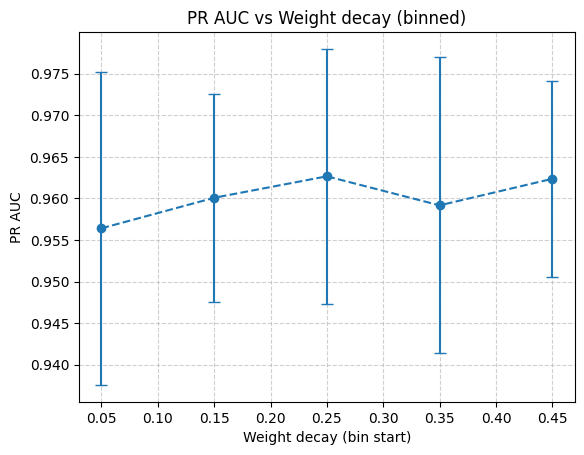

In [74]:
import numpy as np
import matplotlib.pyplot as plt

dropout_bins = [0.0, 0.1, 0.2, 0.3, 0.4]

bin_means = []
bin_stds = []

for b in dropout_bins:
    mask = (
        (df['weight_decay'] >= b) &
        (df['weight_decay'] < b + 0.1)
    )
    bin_df = df[mask]

    bin_means.append(bin_df['value'].mean())
    bin_stds.append(bin_df['value'].std())

# Plot with error bars (much better than raw dots)
bin_centers = [b + 0.05 for b in dropout_bins]

plt.errorbar(
    bin_centers,
    bin_means,
    yerr=bin_stds,
    fmt='o--',
    capsize=4
)

plt.xlabel("Weight decay (bin start)")
plt.ylabel("PR AUC")
plt.title("PR AUC vs Weight decay (binned)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

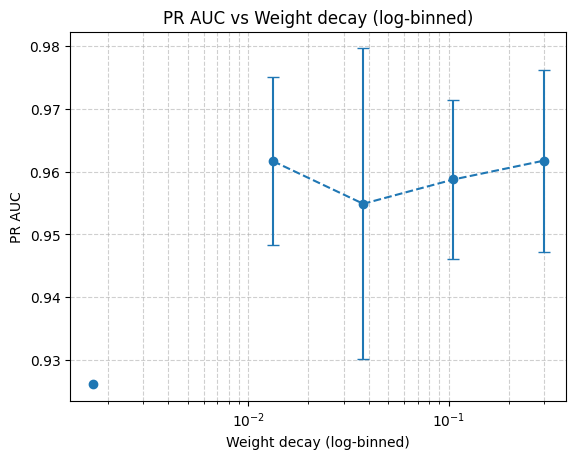

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1) DEFINE LOG-SPACED BINS
# ---------------------------

n_bins = 6  # adjust if you want more / fewer buckets
wd_bins = np.logspace(np.log10(1e-3), np.log10(0.5), n_bins + 1)

# ---------------------------
# 2) BIN & AGGREGATE
# ---------------------------

bin_means = []
bin_stds = []
bin_centers = []

for lo, hi in zip(wd_bins[:-1], wd_bins[1:]):
    mask = (
        (df["weight_decay"] >= lo) &
        (df["weight_decay"] < hi)
    )
    bin_df = df[mask]

    bin_means.append(bin_df["value"].mean())
    bin_stds.append(bin_df["value"].std())

    # geometric mean is the correct center for log bins
    bin_centers.append(np.sqrt(lo * hi))

# ---------------------------
# 3) PLOT
# ---------------------------

plt.errorbar(
    bin_centers,
    bin_means,
    yerr=bin_stds,
    fmt="o--",
    capsize=4,
)

plt.xscale("log")
plt.xlabel("Weight decay (log-binned)")
plt.ylabel("PR AUC")
plt.title("PR AUC vs Weight decay (log-binned)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

### New Study: 10x Augmentation

/pdo/users/pablomer/mnt/tess/models/vetting/20251220-augmentation_study/pablomer_optuna_20251220/optuna_trials_trial_90.csv
   trial_number     value     state  use_augmentation  learning_rate  \
0             0  0.963327  COMPLETE             False       0.000080   
1             1  0.986504  COMPLETE             False       0.000003   
2             2  0.967244  COMPLETE              True       0.000080   
3             3  0.966902  COMPLETE             False       0.000080   
4             4  0.987989  COMPLETE              True       0.000010   

   weight_decay  pre_logits_dropout_rate  
0      0.041917                 0.283229  
1      0.001000                 0.000000  
2      0.022361                 0.200000  
3      0.105737                 0.100000  
4      0.004729                 0.300000  


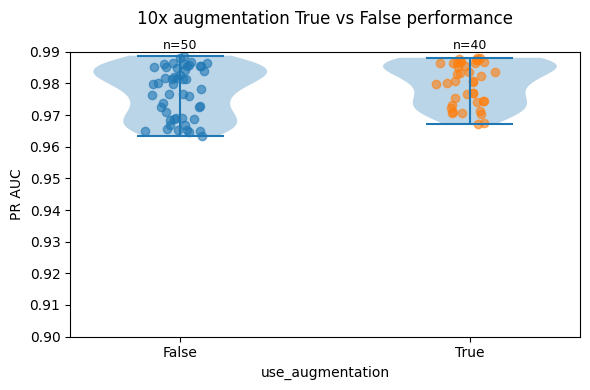

use_augmentation True: (40,), False: (50,)
use_augmentation True >=0.98: 23, >=0.97: 38
use_augmentation False >=0.98: 24, >=0.97: 36


In [76]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251220-augmentation_study/pablomer_optuna_20251220/'

file_name = 'optuna_trials_trial_90.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'use_augmentation', title='10x augmentation True vs False performance')
calculate_above_threshold(df, 'use_augmentation', 0.98, 0.97)

---

# Repeating the studies with log scale and corrected tfrecords

/pdo/users/pablomer/mnt/tess/models/vetting/20251219-randomreversestudy/pablomer_optuna_20251219/optuna_trials_trial_90.csv


   trial_number     value     state  random_reverse_time_series  \
0             0  0.944972  COMPLETE                       False   
1             1  0.978277  COMPLETE                       False   
2             2  0.968236  COMPLETE                        True   
3             3  0.970608  COMPLETE                       False   
4             4  0.984469  COMPLETE                        True   

   learning_rate  weight_decay  pre_logits_dropout_rate  
0       0.000080      0.041917                 0.283229  
1       0.000003      0.001000                 0.000000  
2       0.000080      0.022361                 0.200000  
3       0.000080      0.105737                 0.100000  
4       0.000010      0.004729                 0.300000  


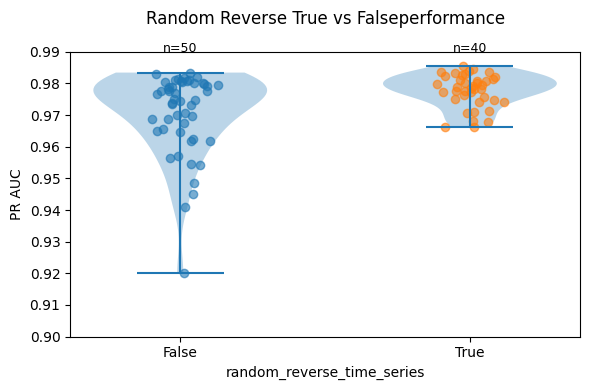

random_reverse_time_series True: (40,), False: (50,)
random_reverse_time_series True >=0.98: 16, >=0.97: 36
random_reverse_time_series False >=0.98: 13, >=0.97: 31


In [77]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251219-randomreversestudy/pablomer_optuna_20251219'

file_name = 'optuna_trials_trial_90.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'random_reverse_time_series', title='Random Reverse True vs Falseperformance')
calculate_above_threshold(df, 'random_reverse_time_series', 0.98, 0.97)

/pdo/users/pablomer/mnt/tess/models/vetting/20251219-pretrainstudy/pablomer_optuna_20251219/optuna_trials_trial_90.csv


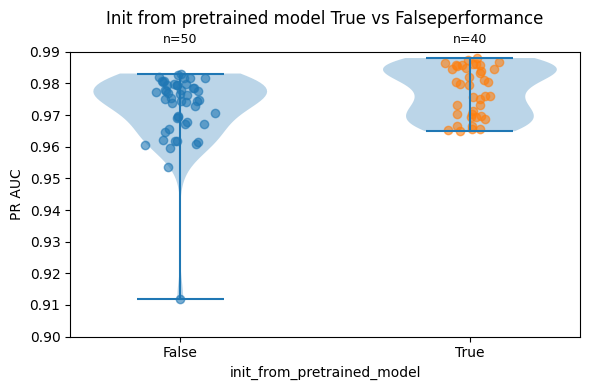

init_from_pretrained_model True: (40,), False: (50,)
init_from_pretrained_model True >=0.98: 19, >=0.97: 30
init_from_pretrained_model False >=0.98: 9, >=0.97: 33


In [78]:
## Pretrain v2
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251219-pretrainstudy/pablomer_optuna_20251219'

file_name = 'optuna_trials_trial_90.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

df.head()

plot_boolean_vs_value(df, 'init_from_pretrained_model', title='Init from pretrained model True vs Falseperformance')
calculate_above_threshold(df, 'init_from_pretrained_model', 0.98, 0.97)

## Repeating for batch norm

/pdo/users/pablomer/mnt/tess/models/vetting/20251219-batchnormstudy/pablomer_optuna_20251219/optuna_trials_trial_100.csv
   trial_number     value     state  use_batch_norm  learning_rate  \
0             0  0.963466  COMPLETE           False       0.000080   
1             1  0.979301  COMPLETE           False       0.000003   
2             2  0.966395  COMPLETE            True       0.000080   
3             3  0.964804  COMPLETE           False       0.000080   
4             4  0.977086  COMPLETE            True       0.000010   

   weight_decay  pre_logits_dropout_rate  
0      0.041917                 0.283229  
1      0.001000                 0.000000  
2      0.022361                 0.200000  
3      0.105737                 0.100000  
4      0.004729                 0.300000  


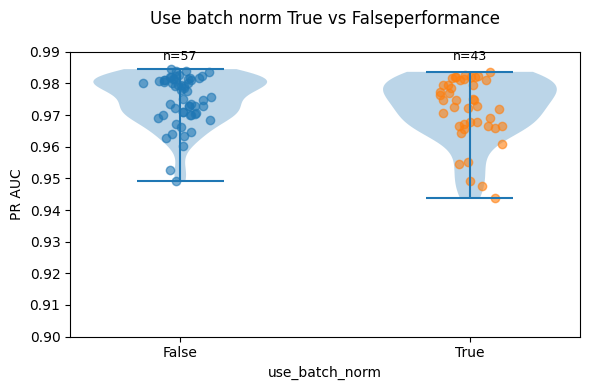

use_batch_norm True: (43,), False: (57,)
use_batch_norm True >=0.98: 11, >=0.97: 27
use_batch_norm False >=0.98: 21, >=0.97: 43


In [79]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251219-batchnormstudy/pablomer_optuna_20251219'

file_name = 'optuna_trials_trial_100.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'use_batch_norm', title='Use batch norm True vs Falseperformance')
calculate_above_threshold(df, 'use_batch_norm', 0.98, 0.97)

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def plot_binned_metric(
    df,
    param_col,
    value_col="value",
    bins=None,
    bin_width=None,
    log=False,
    n_bins=6,
    xlabel=None,
    ylabel="PR AUC",
    title=None,
):
    """
    Plot mean ± std of `value_col` binned over `param_col`.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing results
    param_col : str
        Column to bin (e.g. 'weight_decay', 'pre_logits_dropout_rate')
    value_col : str
        Metric to aggregate (default: 'value')
    bins : array-like or None
        Explicit bin edges (overrides bin_width / log)
    bin_width : float or None
        Linear bin width (e.g. 0.1)
    log : bool
        Use log-spaced bins
    n_bins : int
        Number of bins (only used if log=True and bins=None)
    """

    # ---------------------------
    # Define bins
    # ---------------------------
    if bins is None:
        if log:
            lo = df[param_col][df[param_col] > 0].min()
            hi = df[param_col].max()
            bins = np.logspace(np.log10(lo), np.log10(hi), n_bins + 1)
        else:
            if bin_width is None:
                raise ValueError("Provide bin_width for linear binning")
            lo = df[param_col].min()
            hi = df[param_col].max()
            bins = np.arange(lo, hi + bin_width, bin_width)

    # ---------------------------
    # Bin & aggregate
    # ---------------------------
    bin_means = []
    bin_stds = []
    bin_centers = []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (df[param_col] >= lo) & (df[param_col] < hi)
        sub = df.loc[mask, value_col]

        bin_means.append(sub.mean())
        bin_stds.append(sub.std())

        # center
        if log:
            bin_centers.append(np.sqrt(lo * hi))  # geometric mean
        else:
            bin_centers.append(0.5 * (lo + hi))

    # ---------------------------
    # Plot
    # ---------------------------
    plt.errorbar(
        bin_centers,
        bin_means,
        yerr=bin_stds,
        fmt="o--",
        capsize=4,
    )

    if log:
        plt.xscale("log")

    plt.xlabel(xlabel or param_col)
    plt.ylabel(ylabel)
    plt.title(title or f"{value_col} vs {param_col} (binned)")
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.show()

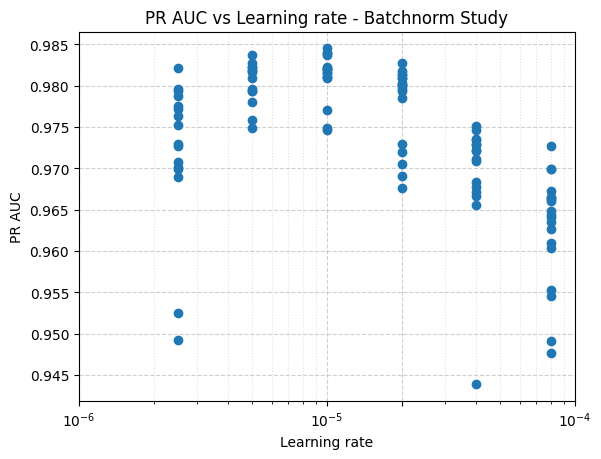

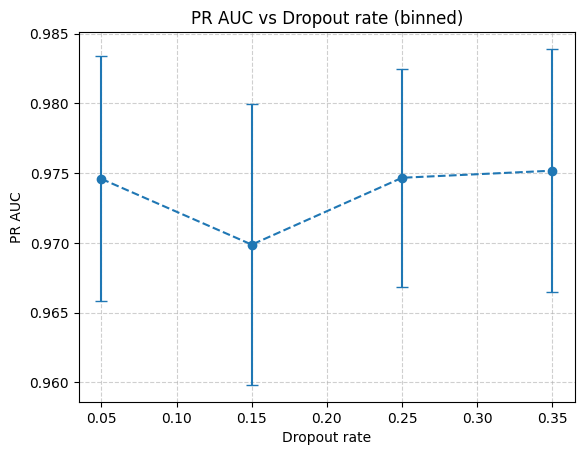

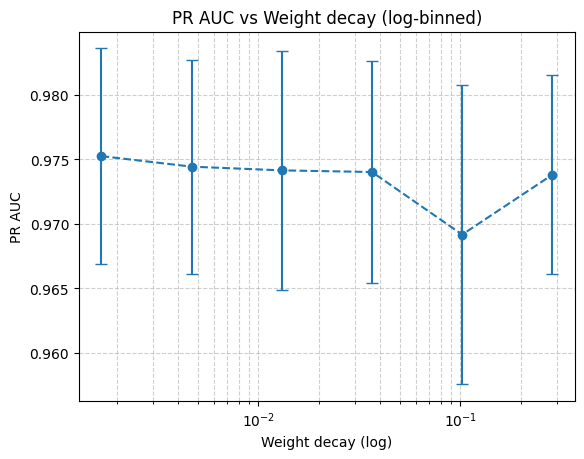

In [81]:
plt.plot(df['learning_rate'],df['value'],'o')
plt.xscale('log')
plt.xticks([1e-6, 1e-5, 2e-5, 1e-4])
plt.xlabel('Learning rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Learning rate - Batchnorm Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()

plot_binned_metric(
    df,
    param_col="pre_logits_dropout_rate",
    bin_width=0.1,
    xlabel="Dropout rate",
    title="PR AUC vs Dropout rate (binned)",
)

plot_binned_metric(
    df,
    param_col="weight_decay",
    log=True,
    n_bins=6,
    xlabel="Weight decay (log)",
    title="PR AUC vs Weight decay (log-binned)",
)

## Repeated study for pretraining

/pdo/users/pablomer/mnt/tess/models/vetting/20251219-pretrainstudy/pablomer_optuna_20251219/optuna_trials_trial_90.csv
   trial_number     value     state  init_from_pretrained_model  \
0             0  0.960464  COMPLETE                       False   
1             1  0.977644  COMPLETE                       False   
2             2  0.966440  COMPLETE                        True   
3             3  0.961982  COMPLETE                       False   
4             4  0.984648  COMPLETE                        True   

   learning_rate  weight_decay  pre_logits_dropout_rate  
0       0.000080      0.041917                 0.283229  
1       0.000003      0.001000                 0.000000  
2       0.000080      0.022361                 0.200000  
3       0.000080      0.105737                 0.100000  
4       0.000010      0.004729                 0.300000  


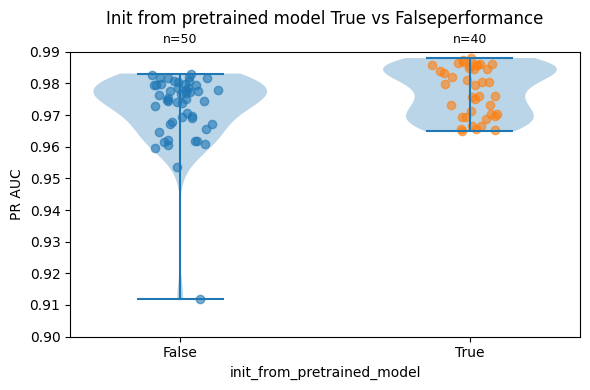

init_from_pretrained_model True: (40,), False: (50,)
init_from_pretrained_model True >=0.98: 19, >=0.97: 30
init_from_pretrained_model False >=0.98: 9, >=0.97: 33


In [82]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251219-pretrainstudy/pablomer_optuna_20251219'

file_name = 'optuna_trials_trial_90.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'init_from_pretrained_model', title='Init from pretrained model True vs Falseperformance')
calculate_above_threshold(df, 'init_from_pretrained_model', 0.98, 0.97)

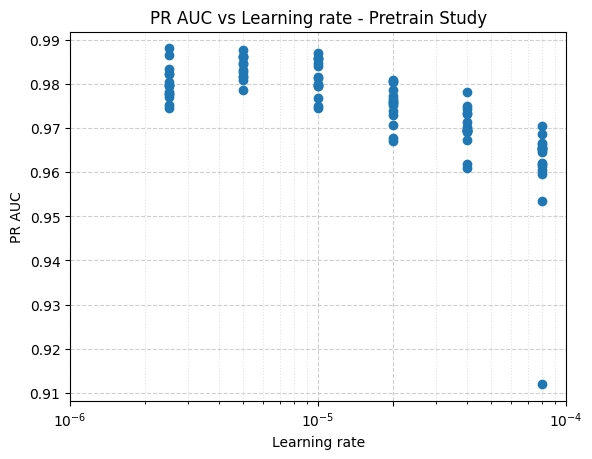

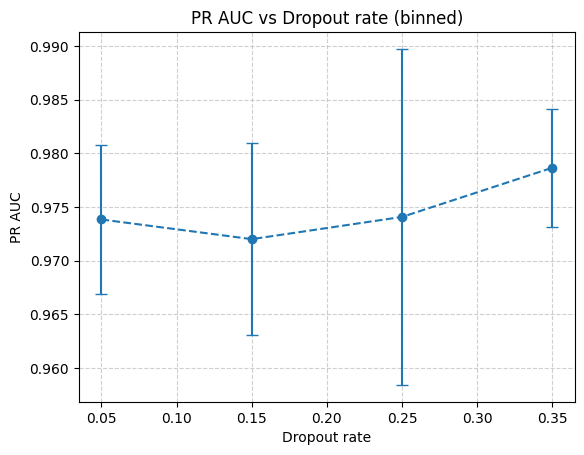

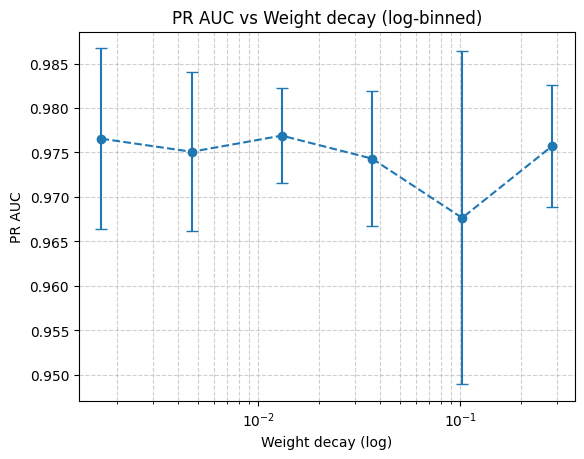

In [83]:
plt.plot(df['learning_rate'],df['value'],'o')
plt.xscale('log')
plt.xticks([1e-6, 1e-5, 2e-5, 1e-4])
plt.xlabel('Learning rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Learning rate - Pretrain Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()

plot_binned_metric(
    df,
    param_col="pre_logits_dropout_rate",
    bin_width=0.1,
    xlabel="Dropout rate",
    title="PR AUC vs Dropout rate (binned)",
)

plot_binned_metric(
    df,
    param_col="weight_decay",
    log=True,
    n_bins=6,
    xlabel="Weight decay (log)",
    title="PR AUC vs Weight decay (log-binned)",
)

## repeated study for time series reversal

/pdo/users/pablomer/mnt/tess/models/vetting/20251219-randomreversestudy/pablomer_optuna_20251219/optuna_trials_trial_100.csv
   trial_number     value     state  random_reverse_time_series  \
0             0  0.944972  COMPLETE                       False   
1             1  0.978277  COMPLETE                       False   
2             2  0.968236  COMPLETE                        True   
3             3  0.970608  COMPLETE                       False   
4             4  0.984469  COMPLETE                        True   

   learning_rate  weight_decay  pre_logits_dropout_rate  
0       0.000080      0.041917                 0.283229  
1       0.000003      0.001000                 0.000000  
2       0.000080      0.022361                 0.200000  
3       0.000080      0.105737                 0.100000  
4       0.000010      0.004729                 0.300000  


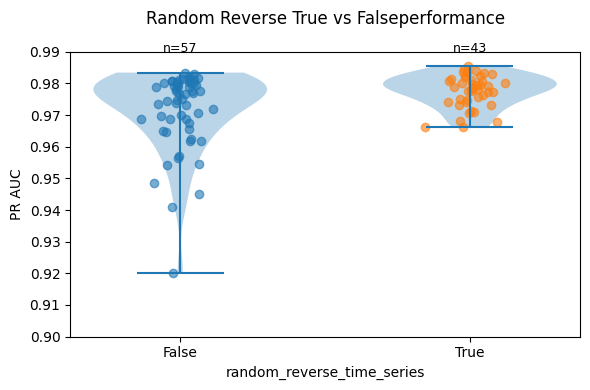

random_reverse_time_series True: (43,), False: (57,)
random_reverse_time_series True >=0.98: 16, >=0.97: 39
random_reverse_time_series False >=0.98: 16, >=0.97: 37


In [84]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251219-randomreversestudy/pablomer_optuna_20251219'

file_name = 'optuna_trials_trial_100.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'random_reverse_time_series', title='Random Reverse True vs Falseperformance')
calculate_above_threshold(df, 'random_reverse_time_series', 0.98, 0.97)

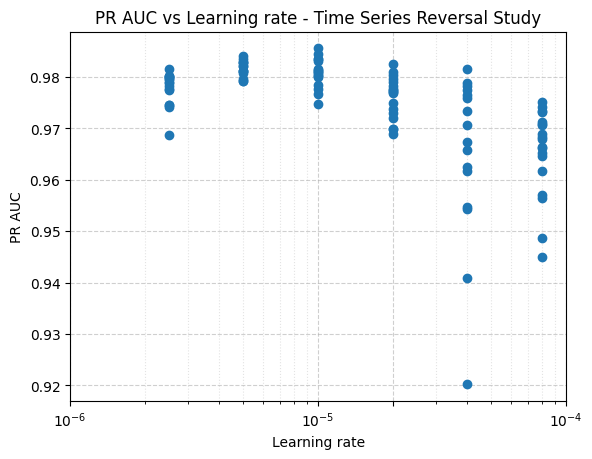

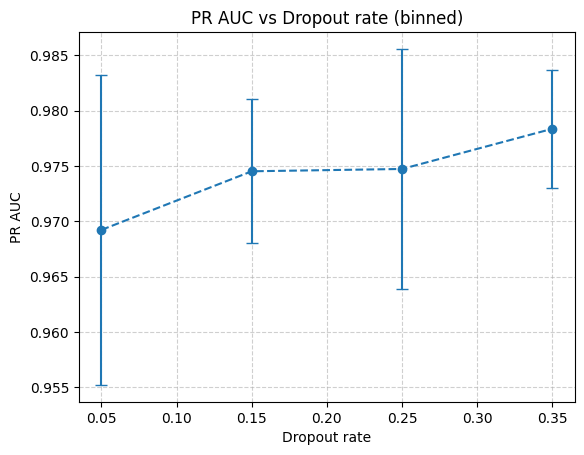

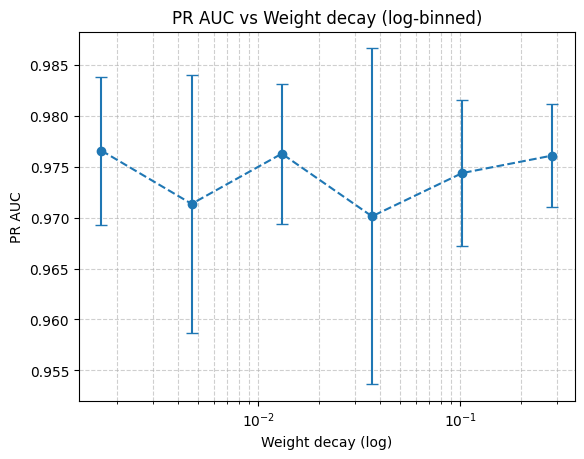

In [85]:
plt.plot(df['learning_rate'],df['value'],'o')
plt.xscale('log')
plt.xticks([1e-6, 1e-5, 2e-5, 1e-4])
plt.xlabel('Learning rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Learning rate - Time Series Reversal Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()

plot_binned_metric(
    df,
    param_col="pre_logits_dropout_rate",
    bin_width=0.1,
    xlabel="Dropout rate",
    title="PR AUC vs Dropout rate (binned)",
)

plot_binned_metric(
    df,
    param_col="weight_decay",
    log=True,
    n_bins=6,
    xlabel="Weight decay (log)",
    title="PR AUC vs Weight decay (log-binned)",
)

## Augmentation study - all plots

/pdo/users/pablomer/mnt/tess/models/vetting/20251220-augmentation_study/pablomer_optuna_20251220/optuna_trials_trial_90.csv
   trial_number     value     state  use_augmentation  learning_rate  \
0             0  0.963327  COMPLETE             False       0.000080   
1             1  0.986504  COMPLETE             False       0.000003   
2             2  0.967244  COMPLETE              True       0.000080   
3             3  0.966902  COMPLETE             False       0.000080   
4             4  0.987989  COMPLETE              True       0.000010   

   weight_decay  pre_logits_dropout_rate  
0      0.041917                 0.283229  
1      0.001000                 0.000000  
2      0.022361                 0.200000  
3      0.105737                 0.100000  
4      0.004729                 0.300000  


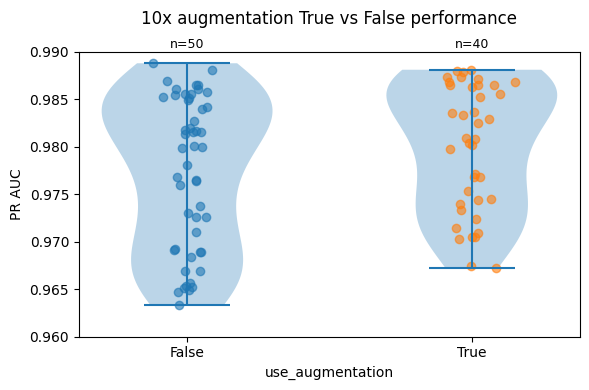

use_augmentation True: (40,), False: (50,)
use_augmentation True >=0.98: 23, >=0.97: 38
use_augmentation False >=0.98: 24, >=0.97: 36


In [91]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251220-augmentation_study/pablomer_optuna_20251220/'

file_name = 'optuna_trials_trial_90.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'use_augmentation', title='10x augmentation True vs False performance',ylim=(0.96,0.99))
calculate_above_threshold(df, 'use_augmentation', 0.98, 0.97)

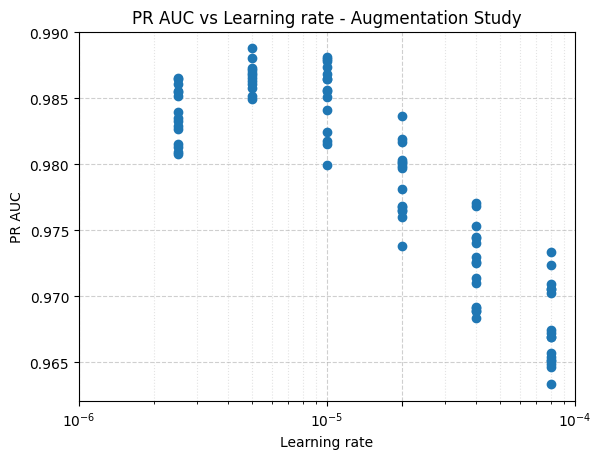

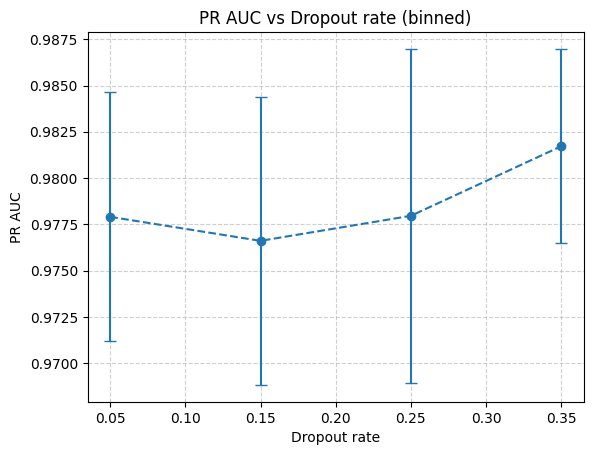

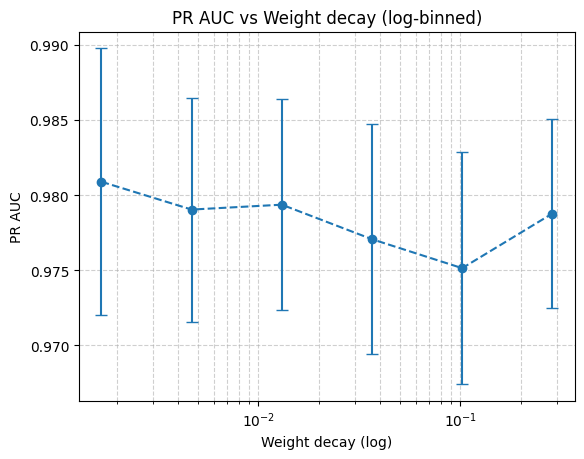

In [87]:
plt.plot(df['learning_rate'],df['value'],'o')
plt.xscale('log')
plt.xticks([1e-6, 1e-5, 2e-5, 1e-4])
plt.xlabel('Learning rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Learning rate - Augmentation Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()

plot_binned_metric(
    df,
    param_col="pre_logits_dropout_rate",
    bin_width=0.1,
    xlabel="Dropout rate",
    title="PR AUC vs Dropout rate (binned)",
)

plot_binned_metric(
    df,
    param_col="weight_decay",
    log=True,
    n_bins=6,
    xlabel="Weight decay (log)",
    title="PR AUC vs Weight decay (log-binned)",
)

---

## Phase 2 Studies

### Pretraining

/pdo/users/pablomer/mnt/tess/models/vetting/20251221-pretrain-phase2-study/pablomer_optuna_20251221/optuna_trials_trial_100.csv
   trial_number     value     state  init_from_pretrained_model  \
0             0  0.980193  COMPLETE                       False   
1             1  0.986606  COMPLETE                        True   
2             2  0.982023  COMPLETE                       False   
3             3  0.980228  COMPLETE                       False   
4             4  0.982853  COMPLETE                        True   

   learning_rate  weight_decay  pre_logits_dropout_rate  
0       0.000007      0.004579                 0.231204  
1       0.000008      0.001000                 0.200000  
2       0.000005      0.003564                 0.300000  
3       0.000007      0.001888                 0.250000  
4       0.000004      0.006727                 0.350000  


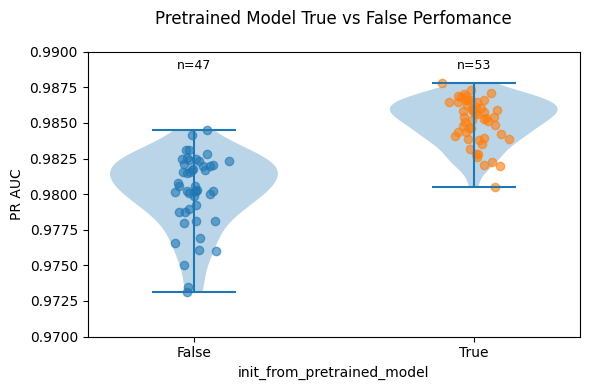

init_from_pretrained_model True: (53,), False: (47,)
init_from_pretrained_model True >=0.9825: 49, >=0.98: 53
init_from_pretrained_model False >=0.9825: 6, >=0.98: 32


In [97]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251221-pretrain-phase2-study/pablomer_optuna_20251221'

file_name = 'optuna_trials_trial_100.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'init_from_pretrained_model', title='Pretrained Model True vs False Perfomance',ylim=(0.97,0.99))
calculate_above_threshold(df, 'init_from_pretrained_model', 0.9825, 0.98)

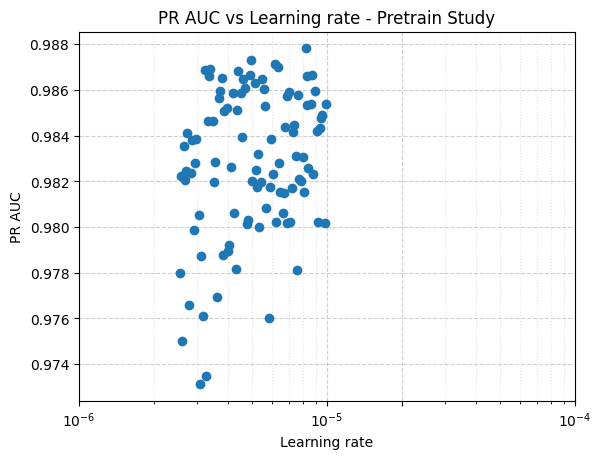

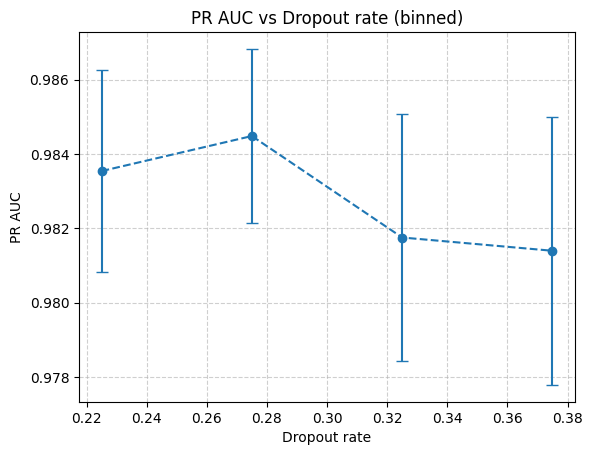

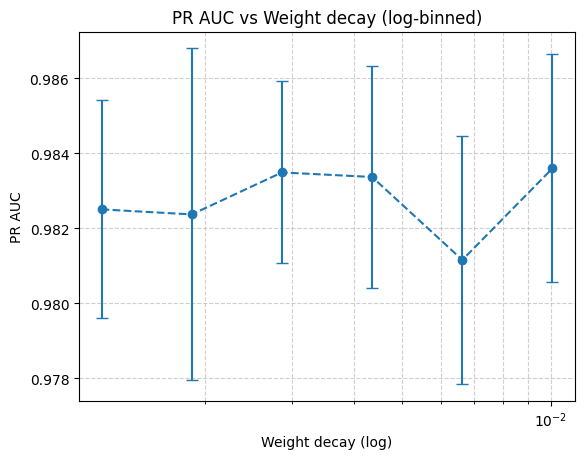

In [98]:
plt.plot(df['learning_rate'],df['value'],'o')
plt.xscale('log')
plt.xticks([1e-6, 1e-5, 2e-5, 1e-4])
plt.xlabel('Learning rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Learning rate - Pretrain Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()

plot_binned_metric(
    df,
    param_col="pre_logits_dropout_rate",
    bin_width=0.05,
    xlabel="Dropout rate",
    title="PR AUC vs Dropout rate (binned)",
)

plot_binned_metric(
    df,
    param_col="weight_decay",
    log=True,
    n_bins=6,
    xlabel="Weight decay (log)",
    title="PR AUC vs Weight decay (log-binned)",
)

In [99]:
df.head()

,trial_number,value,state,init_from_pretrained_model,learning_rate,weight_decay,pre_logits_dropout_rate
0,0,0.980193,COMPLETE,False,0.000007,0.004579,0.231204
1,1,0.986606,COMPLETE,True,0.000008,0.001000,0.200000
2,2,0.982023,COMPLETE,False,0.000005,0.003564,0.300000
3,3,0.980228,COMPLETE,False,0.000007,0.001888,0.250000
4,4,0.982853,COMPLETE,True,0.000004,0.006727,0.350000


### Batch Norm

/pdo/users/pablomer/mnt/tess/models/vetting/20251221-batchnorm-phase2-study/pablomer_optuna_20251221/optuna_trials_trial_100.csv
   trial_number     value     state  use_batch_norm  learning_rate  \
0             0  0.983528  COMPLETE           False       0.000011   
1             1  0.972812  COMPLETE            True       0.000015   
2             2  0.981861  COMPLETE           False       0.000007   
3             3  0.985153  COMPLETE           False       0.000012   
4             4  0.982144  COMPLETE            True       0.000004   

   weight_decay  pre_logits_dropout_rate  
0      0.015751                 0.054607  
1      0.001000                 0.000000  
2      0.010000                 0.175000  
3      0.003162                 0.087500  
4      0.031623                 0.262500  


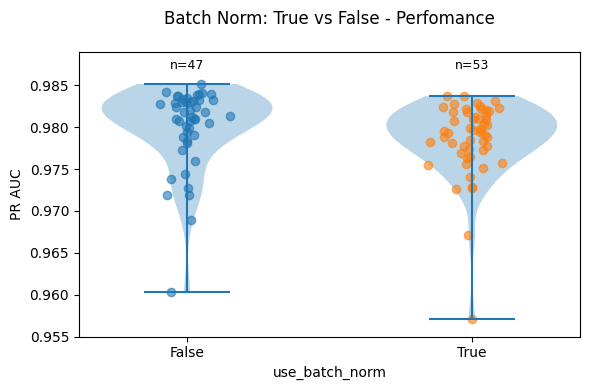

use_batch_norm True: (53,), False: (47,)
use_batch_norm True >=0.9825: 6, >=0.98: 22
use_batch_norm False >=0.9825: 18, >=0.98: 32


In [104]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251221-batchnorm-phase2-study/pablomer_optuna_20251221'

file_name = 'optuna_trials_trial_100.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'use_batch_norm', title='Batch Norm: True vs False - Perfomance',ylim=(0.955,0.989))
calculate_above_threshold(df, 'use_batch_norm', 0.9825, 0.98)

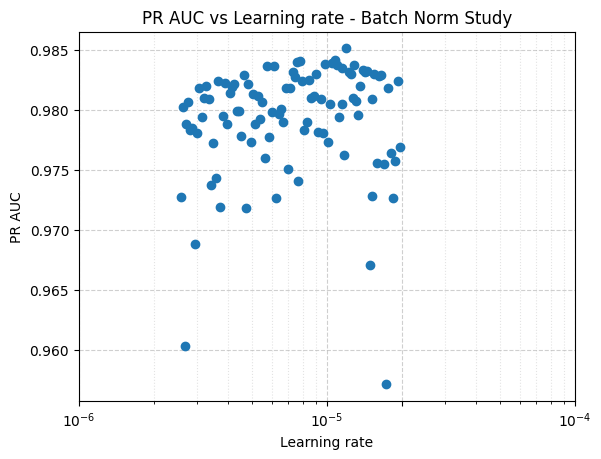

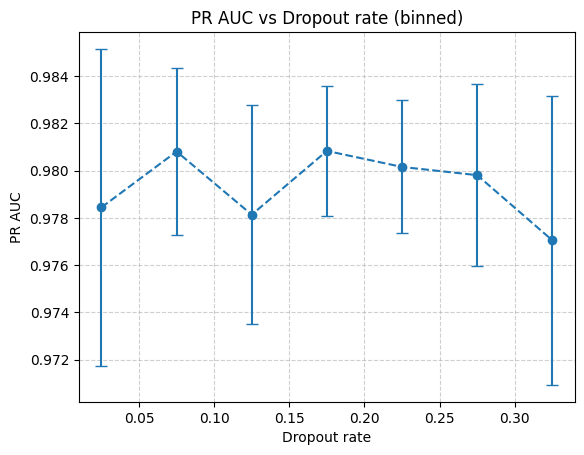

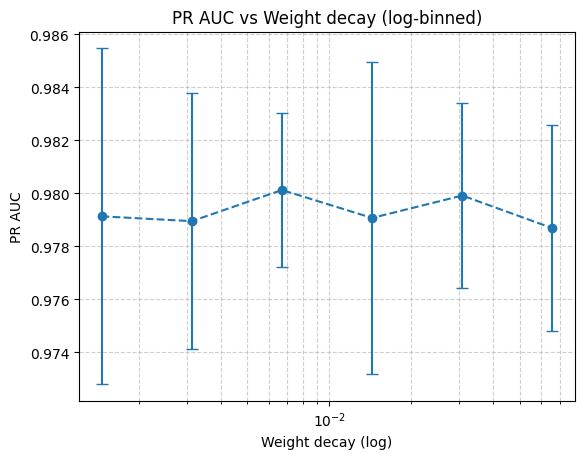

In [105]:
plt.plot(df['learning_rate'],df['value'],'o')
plt.xscale('log')
plt.xticks([1e-6, 1e-5, 2e-5, 1e-4])
plt.xlabel('Learning rate')
plt.ylabel('PR AUC')
plt.title('PR AUC vs Learning rate - Batch Norm Study')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':',  alpha=0.35)
plt.show()

plot_binned_metric(
    df,
    param_col="pre_logits_dropout_rate",
    bin_width=0.05,
    xlabel="Dropout rate",
    title="PR AUC vs Dropout rate (binned)",
)

plot_binned_metric(
    df,
    param_col="weight_decay",
    log=True,
    n_bins=6,
    xlabel="Weight decay (log)",
    title="PR AUC vs Weight decay (log-binned)",
)

## Time Series Reversal

/pdo/users/pablomer/mnt/tess/models/vetting/20251221-reverse-phase2-study/pablomer_optuna_20251221/optuna_trials_trial_100.csv
   trial_number     value     state  random_reverse_time_series  \
0             0  0.979537  COMPLETE                       False   
1             1  0.981637  COMPLETE                        True   
2             2  0.978729  COMPLETE                       False   
3             3  0.978361  COMPLETE                       False   
4             4  0.984818  COMPLETE                        True   

   learning_rate  weight_decay  pre_logits_dropout_rate  
0       0.000014      0.013782                 0.231204  
1       0.000017      0.001000                 0.200000  
2       0.000010      0.008944                 0.300000  
3       0.000014      0.002991                 0.250000  
4       0.000007      0.026750                 0.350000  


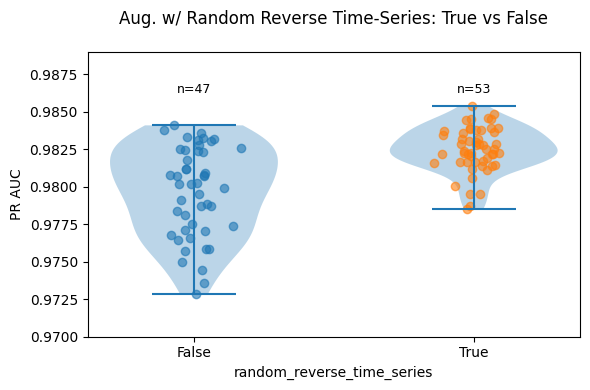

random_reverse_time_series True: (53,), False: (47,)
random_reverse_time_series True >=0.9825: 27, >=0.98: 49
random_reverse_time_series False >=0.9825: 11, >=0.98: 25


In [111]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251221-reverse-phase2-study/pablomer_optuna_20251221'

file_name = 'optuna_trials_trial_100.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'random_reverse_time_series', title='Aug. w/ Random Reverse Time-Series: True vs False',ylim=(0.97,0.989))
calculate_above_threshold(df, 'random_reverse_time_series', 0.9825, 0.98)

## Phase 2 - Augmentation (10x drop data)

In [ ]:
import os

study_directory= '/pdo/users/pablomer/mnt/tess/models/vetting/20251221-augmentation-phase2-study/pablomer_optuna_20251221'

file_name = 'optuna_trials_trial_100.csv'

path = os.path.join(study_directory, file_name)

print(path)
import pandas as pd

df=pd.read_csv(path)

print(df.head())

plot_boolean_vs_value(df, 'use_augmentation', title='Aug. w/ Random Reverse Time-Series: True vs False',ylim=(0.97,0.989))
calculate_above_threshold(df, 'use_augmentation', 0.9825, 0.98)

/pdo/users/pablomer/mnt/tess/models/vetting/20251221-augmentation-phase2-study/pablomer_optuna_20251221/optuna_trials_trial_100.csv
   trial_number     value     state  use_augmentation  learning_rate  \
0             0  0.978849  COMPLETE             False       0.000007   
1             1  0.981877  COMPLETE              True       0.000008   
2             2  0.980350  COMPLETE             False       0.000005   
3             3  0.980774  COMPLETE             False       0.000007   
4             4  0.979518  COMPLETE              True       0.000004   

   weight_decay  pre_logits_dropout_rate  
0      0.003473                 0.135104  
1      0.001000                 0.100000  
2      0.002828                 0.212500  
3      0.001682                 0.156250  
4      0.004757                 0.268750  


## Cosine vs No-Cosine Trial-30 Comparison

This section combines the two trial-30 CSV files, adds a `cosine` flag, and compares PR AUC distributions and binned trends for key hyperparameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve paths robustly whether notebook runs from repo root or from util_notebooks/
path_candidates = [
    Path("optuna_cosine"),
    Path("../optuna_cosine"),
    Path("../../optuna_cosine"),
]
optuna_dir = next((p for p in path_candidates if p.exists()), None)
if optuna_dir is None:
    raise FileNotFoundError("Could not locate optuna_cosine directory from current working directory.")

base_csv = optuna_dir / "base_optuna_trials_trial_30.csv"
cosine_csv = optuna_dir / "cosine_optuna_trials_trial_30.csv"
out_csv = optuna_dir / "combined_base_vs_cosine_trial_30.csv"

base_df = pd.read_csv(base_csv).copy()
cosine_df = pd.read_csv(cosine_csv).copy()

base_df["cosine"] = False
cosine_df["cosine"] = True

combined_df = pd.concat([base_df, cosine_df], ignore_index=True)
combined_df.to_csv(out_csv, index=False)

print(f"Saved combined CSV: {out_csv}")
print(combined_df[["trial_number", "value", "learning_rate", "weight_decay", "pre_logits_dropout_rate", "cosine"]].head())
print("\nCounts by cosine:")
print(combined_df["cosine"].value_counts())

Saved combined CSV: ../../optuna_cosine/combined_base_vs_cosine_trial_30.csv
   trial_number     value  learning_rate  weight_decay  \
0             0  0.977419       0.000005      0.001435   
1             1  0.968730       0.000020      0.001000   
2             2  0.972705       0.000020      0.022361   
3             3  0.953170       0.000080      0.105737   
4             4  0.973819       0.000040      0.004729   

   pre_logits_dropout_rate  cosine  
0                  0.34647   False  
1                  0.00000   False  
2                  0.20000   False  
3                  0.10000   False  
4                  0.30000   False  

Counts by cosine:
cosine
False    30
True     30
Name: count, dtype: int64


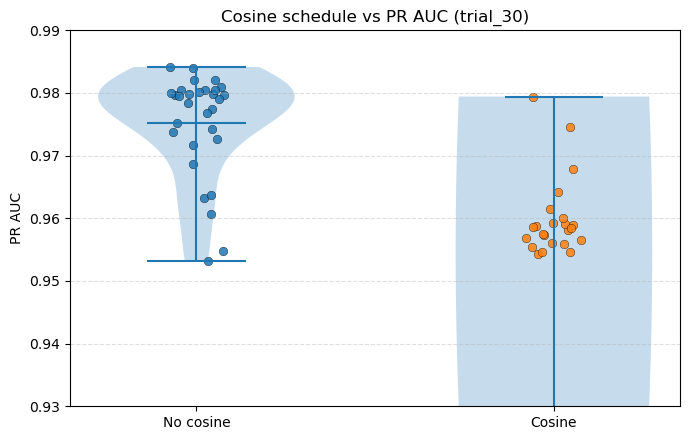

In [10]:
# Cosine (True/False) vs PR AUC, in the same spirit as boolean-vs-value plots
plt.figure(figsize=(7, 4.5))

vals_no = combined_df.loc[combined_df["cosine"] == False, "value"].values
vals_yes = combined_df.loc[combined_df["cosine"] == True, "value"].values

# Violin overlay
parts = plt.violinplot([vals_no, vals_yes], positions=[0, 1], widths=0.55, showmeans=True)
for body in parts["bodies"]:
    body.set_alpha(0.25)

# Jittered scatter overlay
rng = np.random.default_rng(42)
for x_pos, vals, color in [(0, vals_no, "tab:blue"), (1, vals_yes, "tab:orange")]:
    x_jitter = x_pos + rng.uniform(-0.08, 0.08, size=len(vals))
    plt.scatter(x_jitter, vals, alpha=0.85, s=38, color=color, edgecolor="black", linewidth=0.3)

plt.xticks([0, 1], ["No cosine", "Cosine"])
plt.ylabel("PR AUC")
plt.title("Cosine schedule vs PR AUC (trial_30)")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.ylim(0.93,0.99)
plt.tight_layout()
plt.show()

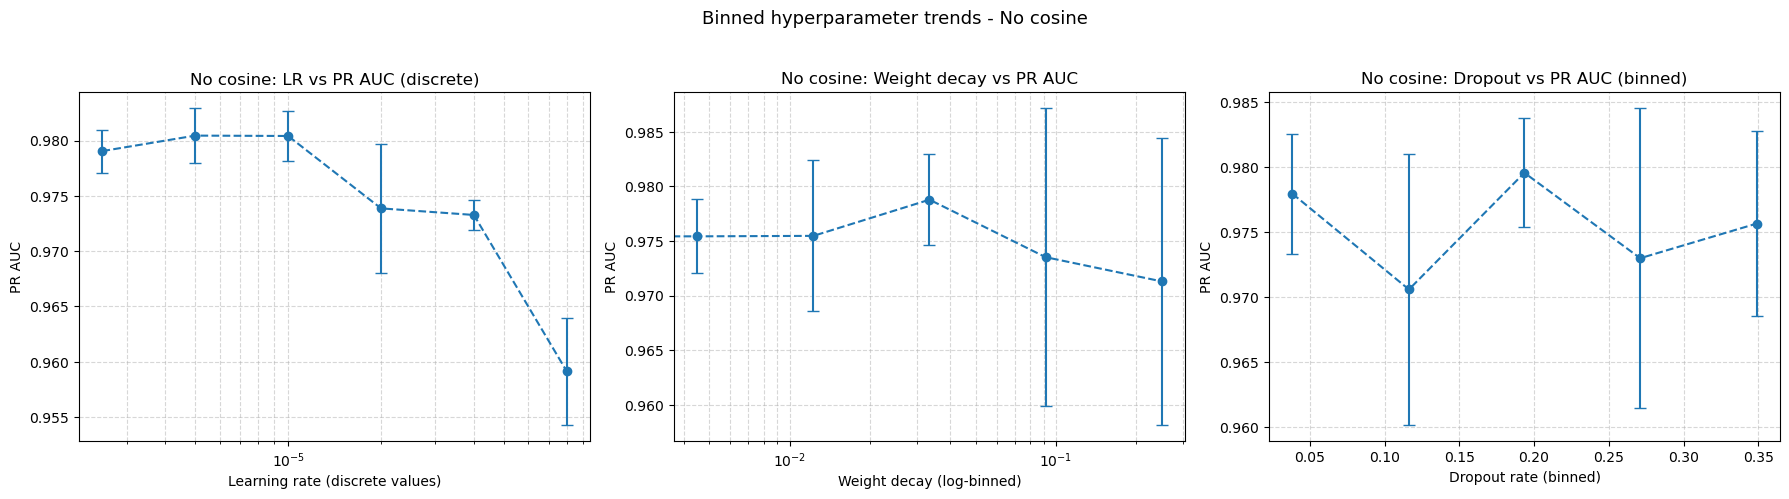

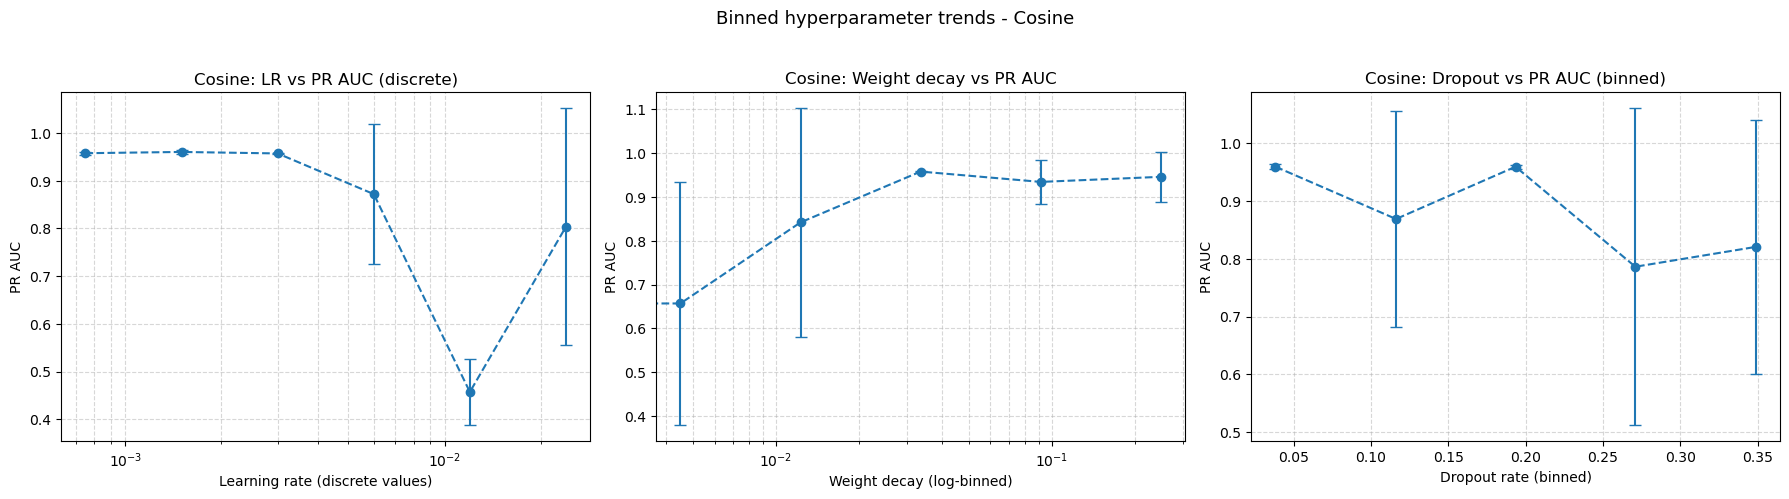

In [4]:
def _plot_binned_with_errorbar(
    ax,
    df,
    x_col,
    y_col="value",
    n_bins=6,
    log_binning=False,
    log_xaxis=False,
    xlabel=None,
    title=None,
):
    x = df[x_col].astype(float)
    y = df[y_col].astype(float)

    if log_binning:
        x_pos = x[x > 0]
        bins = np.logspace(np.log10(x_pos.min()), np.log10(x_pos.max()), n_bins + 1)
    else:
        bins = np.linspace(x.min(), x.max(), n_bins + 1)

    binned = pd.cut(x, bins=bins, include_lowest=True, duplicates="drop")
    stats = (
        pd.DataFrame({"x": x, "y": y, "bin": binned})
        .groupby("bin", observed=False)["y"]
        .agg(["mean", "std", "count"])
        .dropna(subset=["mean"])
    )

    if stats.empty:
        ax.set_title((title or x_col) + " (no valid bins)")
        ax.set_xlabel(xlabel or x_col)
        ax.set_ylabel("PR AUC")
        ax.grid(True, linestyle="--", alpha=0.4)
        return

    centers = []
    for interval in stats.index:
        if log_binning:
            centers.append(np.sqrt(interval.left * interval.right))
        else:
            centers.append((interval.left + interval.right) / 2)

    ax.errorbar(
        centers,
        stats["mean"].values,
        yerr=stats["std"].fillna(0).values,
        fmt="o--",
        capsize=4,
    )

    if log_xaxis:
        ax.set_xscale("log")

    ax.set_xlabel(xlabel or x_col)
    ax.set_ylabel("PR AUC")
    ax.set_title(title or f"PR AUC vs {x_col} (binned)")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)


for cosine_flag, label in [(False, "No cosine"), (True, "Cosine")]:
    subset = combined_df.loc[combined_df["cosine"] == cosine_flag].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    # LR is discrete in this search space, so aggregate by exact LR values (no binning).
    lr_stats = (
        subset.groupby("learning_rate", as_index=False)["value"]
        .agg(mean="mean", std="std", count="count")
        .sort_values("learning_rate")
    )

    axes[0].errorbar(
        lr_stats["learning_rate"].values,
        lr_stats["mean"].values,
        yerr=lr_stats["std"].fillna(0).values,
        fmt="o--",
        capsize=4,
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Learning rate (discrete values)")
    axes[0].set_ylabel("PR AUC")
    axes[0].set_title(f"{label}: LR vs PR AUC (discrete)")
    axes[0].grid(True, which="both", linestyle="--", alpha=0.5)

    _plot_binned_with_errorbar(
        axes[1],
        subset,
        x_col="weight_decay",
        n_bins=6,
        log_binning=True,
        log_xaxis=True,
        xlabel="Weight decay (log-binned)",
        title=f"{label}: Weight decay vs PR AUC",
    )

    _plot_binned_with_errorbar(
        axes[2],
        subset,
        x_col="pre_logits_dropout_rate",
        n_bins=5,
        log_binning=False,
        log_xaxis=False,
        xlabel="Dropout rate (binned)",
        title=f"{label}: Dropout vs PR AUC (binned)",
    )

    fig.suptitle(f"Binned hyperparameter trends - {label}", y=1.03, fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
from pathlib import Path

# Set your PR AUC threshold here
threshold = 0.97

# Reuse combined_df if already in memory; otherwise load from combined CSV
if "combined_df" not in globals():
    path_candidates = [Path("optuna_cosine"), Path("../optuna_cosine"), Path("../../optuna_cosine")]
    optuna_dir = next((p for p in path_candidates if p.exists()), None)
    if optuna_dir is None:
        raise FileNotFoundError("Could not locate optuna_cosine directory from current working directory.")
    combined_df = pd.read_csv(optuna_dir / "combined_base_vs_cosine_trial_30.csv")

print(f"Threshold: PR AUC > {threshold}")

# Overall
n_total = len(combined_df)
n_above = int((combined_df["value"] > threshold).sum())
print(f"Overall: {n_above}/{n_total} ({100*n_above/n_total:.1f}%)")

# By cosine flag
summary = (
    combined_df.assign(above_threshold=combined_df["value"] > threshold)
    .groupby("cosine", as_index=False)
    .agg(total_trials=("value", "size"), above_threshold=("above_threshold", "sum"))
)
summary["pct_above"] = 100.0 * summary["above_threshold"] / summary["total_trials"]

print("\nBy cosine setting:")
for _, row in summary.iterrows():
    label = "Cosine" if bool(row["cosine"]) else "No cosine"
    print(
        f"- {label}: {int(row['above_threshold'])}/{int(row['total_trials'])} "
        f"({row['pct_above']:.1f}%)"
    )

summary